In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for visuals
sns.set_theme(style="whitegrid")

# Load the dataset using a relative path
filepath = "../data/Raw/version 1.xlsx"
df = pd.read_excel(filepath)

# 1. Basic Information
print("--- Dataset Shape ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")

# 2. Data Types and Non-Null Counts
print("--- DataFrame Info ---")
df.info()

# 3. Missing Value Audit
print("\n--- Missing Values Per Column ---")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0]) 

--- Dataset Shape ---
Rows: 1848, Columns: 41

--- DataFrame Info ---
<class 'pandas.DataFrame'>
RangeIndex: 1848 entries, 0 to 1847
Data columns (total 41 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Actual data of                               1847 non-null   str    
 1   Day of the week                              1847 non-null   str    
 2   Max. Demand at eve. peak (Generation end)    1847 non-null   float64
 3   Max. Demand at eve. peak (Sub-station end)   1847 non-null   float64
 4   Highest Generation (Generation end)          1847 non-null   float64
 5   Minimum Generation (Generation end)          1847 non-null   float64
 6   Day-peak Generation (Generation end)         1847 non-null   float64
 7   Evening-peak Generation (Generation end)     1847 non-null   float64
 8   Minimum Generation Forecast up to 8:00 hrs.  1847 non-null   float64
 9   Maximum Tempera

In [7]:
# 
df = df.dropna(subset=['Max. Demand at eve. peak (Generation end)'])

# 2. Convert 'Actual data of' to a proper DateTime object
df['Actual data of'] = pd.to_datetime(df['Actual data of'], errors='coerce')
                                      
df.set_index('Actual data of', inplace=True)

print("--- Zero vs NaN Audit (Load Shedding) ---")
print(f"Total valid rows: {len(df)}")

dhaka_zeros = (df['Dhaka_load'] == 0).sum()
dhaka_nans = df['Dhaka_load'].isnull().sum()
print(f"Dhaka -> Zeros (No Shortfall): {dhaka_zeros} | Missing (NaN): {dhaka_nans}")

khulna_zeros = (df['Khulna_load'] == 0).sum()
khulna_nans = df['Khulna_load'].isnull().sum()
print(f"Khulna -> Zeros (No Shortfall): {khulna_zeros} | Missing (NaN): {khulna_nans}")

--- Zero vs NaN Audit (Load Shedding) ---
Total valid rows: 1847
Dhaka -> Zeros (No Shortfall): 1485 | Missing (NaN): 9
Khulna -> Zeros (No Shortfall): 1627 | Missing (NaN): 60


C:\Users\Asus\AppData\Local\Temp\ipykernel_21380\2107643602.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Actual data of'] = pd.to_datetime(df['Actual data of'], errors='coerce')


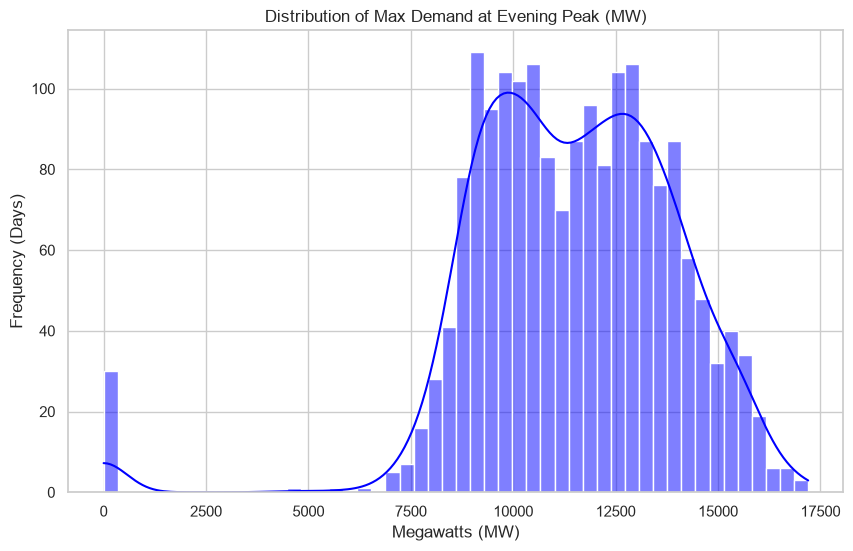

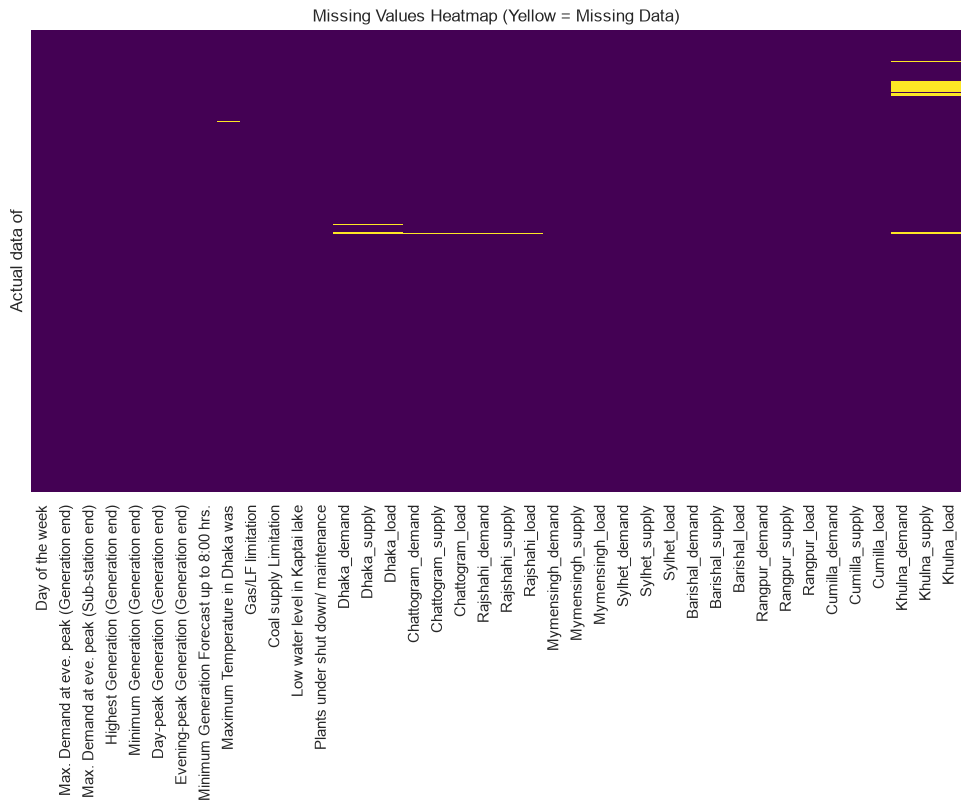

--- Target Variable Statistics ---
count     1847.000000
mean     11438.913914
std       2565.480469
min          0.000000
25%       9780.500000
50%      11528.000000
75%      13226.500000
max      17200.000000
Name: Max. Demand at eve. peak (Generation end), dtype: float64


In [8]:
import os

os.makedirs('../figures', exist_ok=True)

# 1. Target Variable Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Max. Demand at eve. peak (Generation end)'].dropna(), kde=True, bins=50, color='blue')
plt.title('Distribution of Max Demand at Evening Peak (MW)')
plt.xlabel('Megawatts (MW)')
plt.ylabel('Frequency (Days)')
plt.savefig('../figures/01_target_distribution.png', bbox_inches='tight')
plt.show()

# 2. Missing Values Time-Series Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap (Yellow = Missing Data)')
plt.savefig('../figures/02_missing_data_heatmap.png', bbox_inches='tight')
plt.show()

# 3. Descriptive Statistics for Target
print("--- Target Variable Statistics ---")
print(df['Max. Demand at eve. peak (Generation end)'].describe())